In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("marketing_data_enriched.csv")

In [3]:
print("Shape:", df.shape)

Shape: (2240, 44)


In [6]:
print("\nColumns:")
print(df.columns.tolist())


Columns:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Complain', 'Country', 'Income', 'Age', 'Total_Spending', 'Total_Purchases', 'Total_Campaign_Responses', 'Customer_Segment', 'Income_Clean', 'Campaign_Engagement', 'Age_Group', 'Preferred_Channel', 'Total_Children', 'Household_Segment', 'Deal_Purchase_Ratio', 'Deal_Purchase_Rate', 'Web_Purchase_Visit_Ratio', 'Recency_Segment', 'Response_Status']


In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Campaign_Engagement,Age_Group,Preferred_Channel,Total_Children,Household_Segment,Deal_Purchase_Ratio,Deal_Purchase_Rate,Web_Purchase_Visit_Ratio,Recency_Segment,Response_Status
0,1826,1970,Graduation,Divorced,0,0,2014-06-16,0,189,104,...,No Response,35-44,Store,0,No Children,0.071429,7.142857,4.000000,0-30 Days,Responder
1,1,1961,Graduation,Single,0,0,2014-06-15,0,464,5,...,Low Engagement,45-54,Web,0,No Children,0.058824,5.882353,1.400000,0-30 Days,Responder
2,10476,1958,Graduation,Married,0,1,2014-05-13,0,134,11,...,No Response,55-64,Store,1,One Child,0.100000,10.000000,1.500000,0-30 Days,Non-Responder
3,1386,1967,Graduation,Together,1,1,2014-05-11,0,10,0,...,No Response,45-54,Store,2,Two or More Children,0.333333,33.333333,0.142857,0-30 Days,Non-Responder
4,5371,1989,Graduation,Single,1,0,2014-04-08,0,6,16,...,Low Engagement,25-34,Web,1,One Child,0.333333,33.333333,0.428571,0-30 Days,Responder


In [10]:
df.dtypes

ID                                   int64
Year_Birth                           int64
Education                           object
Marital_Status                      object
Kidhome                              int64
Teenhome                             int64
Dt_Customer                 datetime64[ns]
Recency                              int64
MntWines                             int64
MntFruits                            int64
MntMeatProducts                      int64
MntFishProducts                      int64
MntSweetProducts                     int64
MntGoldProds                         int64
NumDealsPurchases                    int64
NumWebPurchases                      int64
NumCatalogPurchases                  int64
NumStorePurchases                    int64
NumWebVisitsMonth                    int64
AcceptedCmp3                         int64
AcceptedCmp4                         int64
AcceptedCmp5                         int64
AcceptedCmp1                         int64
AcceptedCmp

In [9]:
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    errors="coerce"
)

In [16]:
missing = df.isnull().sum()

print("Missing values:")
print(missing[missing > 0])

Missing values:
Age                          3
Income_Clean                 1
Age_Group                    3
Web_Purchase_Visit_Ratio    11
dtype: int64


In [17]:
print("Duplicate IDs:", df["ID"].duplicated().sum())

Duplicate IDs: 0


In [18]:
df.describe()

,ID,Year_Birth,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Income,Age,Total_Spending,Total_Purchases,Total_Campaign_Responses,Income_Clean,Total_Children,Deal_Purchase_Ratio,Deal_Purchase_Rate,Web_Purchase_Visit_Ratio
count,2240.000000,2240.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2237.000000,2240.000000,2240.000000,2240.000000,2239.000000,2240.000000,2240.000000,2240.000000,2229.000000
mean,5592.159821,1968.805804,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,37.525446,...,52237.975446,45.098346,605.798214,12.537054,0.297768,51963.554712,0.950446,0.247299,24.729927,1.092061
min,0.000000,1893.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,...,1730.000000,18.000000,5.000000,0.000000,0.000000,1730.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,...,35538.750000,37.000000,68.750000,6.000000,0.000000,35533.500000,0.000000,0.083333,8.333333,0.333333
50%,5458.500000,1970.000000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,...,51381.500000,44.000000,396.000000,12.000000,0.000000,51381.500000,1.000000,0.200000,20.000000,0.750000
75%,8427.750000,1977.000000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,...,68289.750000,55.000000,1045.500000,18.000000,0.000000,68277.500000,1.000000,0.333333,33.333333,1.500000
max,11191.000000,1996.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,666666.000000,74.000000,2525.000000,32.000000,4.000000,162397.000000,3.000000,15.000000,1500.000000,27.000000
std,3246.662198,11.984069,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,...,25037.955891,11.701917,602.249288,7.205741,0.678381,21410.672116,0.751803,0.356432,35.643157,1.330021


In [15]:
missing[missing > 0]

Age                          3
Income_Clean                 1
Age_Group                    3
Web_Purchase_Visit_Ratio    11
dtype: int64

In [19]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 2240
Columns: 44


In [20]:
print(df[["Age", "Income_Clean", "Age_Group", "Web_Purchase_Visit_Ratio"]].isnull().sum())

Age                          3
Income_Clean                 1
Age_Group                    3
Web_Purchase_Visit_Ratio    11
dtype: int64


In [21]:
print(df.shape)

(2240, 44)


In [22]:
missing_cols = ["Age", "Income_Clean", "Age_Group", "Web_Purchase_Visit_Ratio"]

df[df[missing_cols].isnull().any(axis=1)][
    ["ID", "Year_Birth", "Income", "Age", "Income_Clean",
     "Age_Group", "Web_Purchase_Visit_Ratio"]
]

,ID,Year_Birth,Income,Age,Income_Clean,Age_Group,Web_Purchase_Visit_Ratio
58,10286,1962,83715.0,52.0,83715.0,45-54,NaN
497,1501,1982,160803.0,32.0,160803.0,25-34,NaN
513,11004,1893,60182.0,NaN,60182.0,NaN,0.25
527,9432,1977,666666.0,37.0,NaN,35-44,0.50
742,5832,1960,92556.0,54.0,92556.0,45-54,NaN
827,1150,1899,83532.0,NaN,83532.0,NaN,4.00
842,6428,1950,76842.0,64.0,76842.0,55-64,NaN
1213,8720,1978,51381.5,36.0,51381.5,35-44,NaN
1234,8584,1952,85431.0,62.0,85431.0,55-64,NaN
1826,5555,1975,153924.0,39.0,153924.0,35-44,NaN


In [23]:
df[df["Web_Purchase_Visit_Ratio"].isnull()][
    ["ID", "NumWebPurchases", "NumWebVisitsMonth",
     "Web_Purchase_Visit_Ratio"]
]

,ID,NumWebPurchases,NumWebVisitsMonth,Web_Purchase_Visit_Ratio
58,10286,2,0,NaN
497,1501,0,0,NaN
742,5832,3,0,NaN
842,6428,1,0,NaN
1213,8720,0,0,NaN
1234,8584,2,0,NaN
1826,5555,0,0,NaN
1925,11181,0,0,NaN
2063,6237,23,0,NaN
2112,11074,3,0,NaN


In [24]:
df[df["Web_Purchase_Visit_Ratio"].isnull()][
    ["ID", "NumWebPurchases", "NumWebVisitsMonth",
     "Web_Purchase_Visit_Ratio"]
]

,ID,NumWebPurchases,NumWebVisitsMonth,Web_Purchase_Visit_Ratio
58,10286,2,0,NaN
497,1501,0,0,NaN
742,5832,3,0,NaN
842,6428,1,0,NaN
1213,8720,0,0,NaN
1234,8584,2,0,NaN
1826,5555,0,0,NaN
1925,11181,0,0,NaN
2063,6237,23,0,NaN
2112,11074,3,0,NaN


### Missing Value Decision

- `Age`: 3 missing values were intentionally created because the original birth years resulted in unrealistic ages.
- `Age_Group`: 3 missing values correspond to the invalid age records.
- `Income_Clean`: 1 missing value corresponds to the identified extreme income outlier.
- `Web_Purchase_Visit_Ratio`: 11 missing values occur because `NumWebVisitsMonth = 0`, making the purchase-to-visit ratio undefined. These values were retained as NaN rather than imputed.

## Marketing EDA

In [25]:
#Customer Spending Distribution

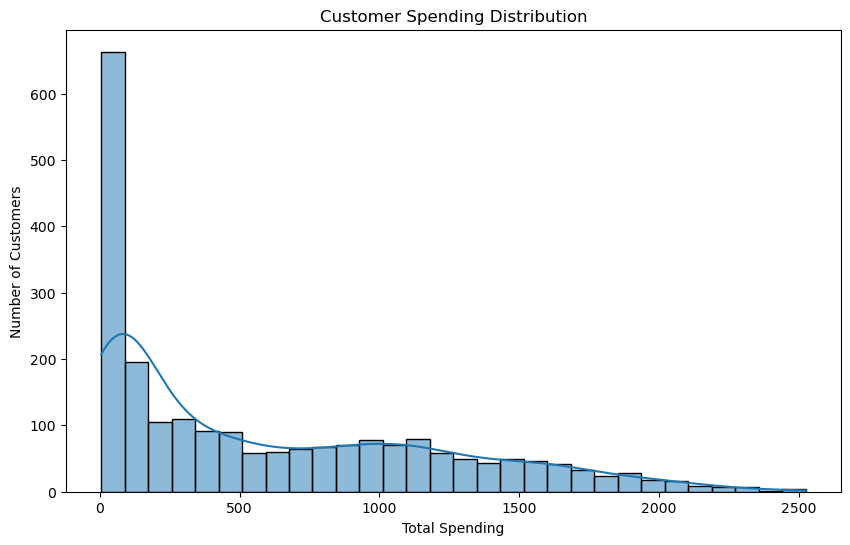

In [26]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Total_Spending"],
    bins=30,
    kde=True
)

plt.title("Customer Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")
plt.show()

Advanced Marketing Analysis: RFM

We'll use RFM-style analysis because this is highly relevant to marketing agencies.

RFM means:

R — Recency: How recently did the customer purchase?
F — Frequency: How often did the customer purchase?
M — Monetary: How much did the customer spend?

In [27]:
df[["Recency", "Total_Purchases", "Total_Spending"]].describe()

,Recency,Total_Purchases,Total_Spending
count,2240.000000,2240.000000,2240.000000
mean,49.109375,12.537054,605.798214
std,28.962453,7.205741,602.249288
min,0.000000,0.000000,5.000000
25%,24.000000,6.000000,68.750000
50%,49.000000,12.000000,396.000000
75%,74.000000,18.000000,1045.500000
max,99.000000,32.000000,2525.000000


In [28]:
#RFM SCORES

In [29]:
# Recency: lower is better
df["R_Score"] = pd.qcut(
    df["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
)

# Frequency: higher is better
df["F_Score"] = pd.qcut(
    df["Total_Purchases"],
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
)

# Monetary: higher is better
df["M_Score"] = pd.qcut(
    df["Total_Spending"],
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
)

In [30]:
df["R_Score"] = df["R_Score"].astype(int)
df["F_Score"] = df["F_Score"].astype(int)
df["M_Score"] = df["M_Score"].astype(int)

In [31]:
df["RFM_Score"] = (
    df["R_Score"] +
    df["F_Score"] +
    df["M_Score"]
)

In [32]:
df[[
    "ID",
    "Recency",
    "Total_Purchases",
    "Total_Spending",
    "R_Score",
    "F_Score",
    "M_Score",
    "RFM_Score"
]].head(10)

,ID,Recency,Total_Purchases,Total_Spending,R_Score,F_Score,M_Score,RFM_Score
0,1826,0,14,1190,5,3,5,13
1,1,0,17,577,5,4,3,12
2,10476,0,10,251,5,3,3,11
3,1386,0,3,11,5,1,1,7
4,5371,0,6,91,5,2,2,9
5,7348,0,16,1192,5,4,5,14
6,4073,0,27,1215,5,5,5,15
7,1991,0,6,96,5,2,2,9
8,4047,0,17,544,5,4,3,12
9,9477,0,17,544,5,4,3,12


In [33]:
#Check the RFM score distribution

In [34]:
df["RFM_Score"].value_counts().sort_index()

RFM_Score
3      81
4     106
5     184
6     192
7     242
8     194
9     236
10    217
11    280
12    189
13    163
14    131
15     25
Name: count, dtype: int64

In [35]:
print("Minimum RFM Score:", df["RFM_Score"].min())
print("Maximum RFM Score:", df["RFM_Score"].max())

Minimum RFM Score: 3
Maximum RFM Score: 15


In [36]:
#RFM marketing segments

In [37]:
def rfm_segment(score):
    if score >= 13:
        return "Champions"
    elif score >= 10:
        return "Loyal Customers"
    elif score >= 7:
        return "Potential Customers"
    elif score >= 5:
        return "Needs Attention"
    else:
        return "At Risk"

df["RFM_Segment"] = df["RFM_Score"].apply(rfm_segment)

In [38]:
df["RFM_Segment"].value_counts()

RFM_Segment
Loyal Customers        686
Potential Customers    672
Needs Attention        376
Champions              319
At Risk                187
Name: count, dtype: int64

In [39]:
df.groupby("RFM_Segment").agg(
    Customers=("ID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Purchases=("Total_Purchases", "mean"),
    Avg_Spending=("Total_Spending", "mean"),
    Avg_Response=("Response", "mean")
).round(2).sort_values("Avg_Spending", ascending=False)

,Customers,Avg_Recency,Avg_Purchases,Avg_Spending,Avg_Response
RFM_Segment,,,,,
Champions,319,21.51,21.40,1343.38,0.34
Loyal Customers,686,50.17,17.72,1000.77,0.18
Potential Customers,672,46.97,9.47,308.45,0.12
Needs Attention,376,58.20,5.20,72.89,0.05
At Risk,187,81.66,4.16,38.68,0.02


In [40]:
#visualization

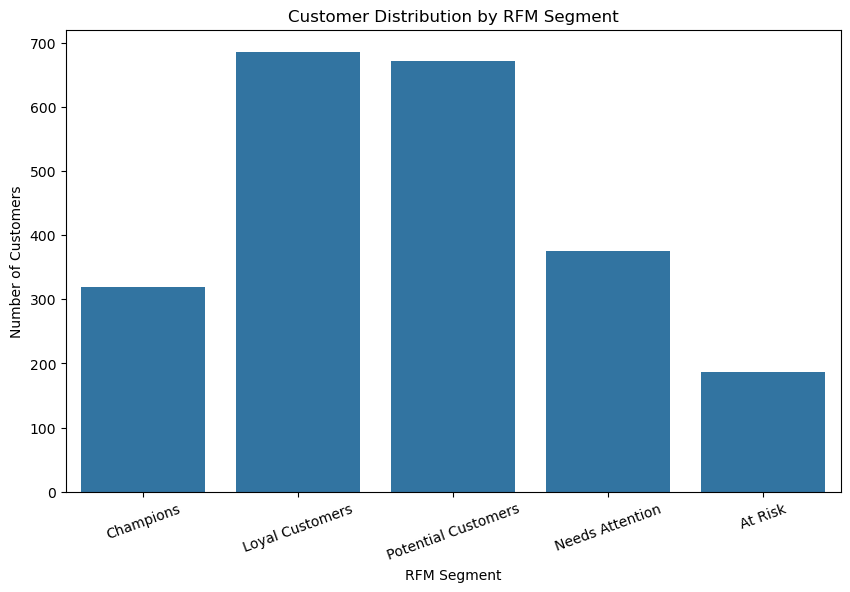

In [41]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="RFM_Segment",
    order=[
        "Champions",
        "Loyal Customers",
        "Potential Customers",
        "Needs Attention",
        "At Risk"
    ]
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("RFM Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

In [42]:
#RFM Segment Performance

In [43]:
rfm_summary = df.groupby("RFM_Segment").agg(
    Avg_Spending=("Total_Spending", "mean"),
    Response_Rate=("Response", "mean")
).reindex([
    "Champions",
    "Loyal Customers",
    "Potential Customers",
    "Needs Attention",
    "At Risk"
])

rfm_summary["Response_Rate"] = rfm_summary["Response_Rate"] * 100

rfm_summary.round(2)

,Avg_Spending,Response_Rate
RFM_Segment,,
Champions,1343.38,33.86
Loyal Customers,1000.77,18.08
Potential Customers,308.45,11.90
Needs Attention,72.89,5.05
At Risk,38.68,1.60


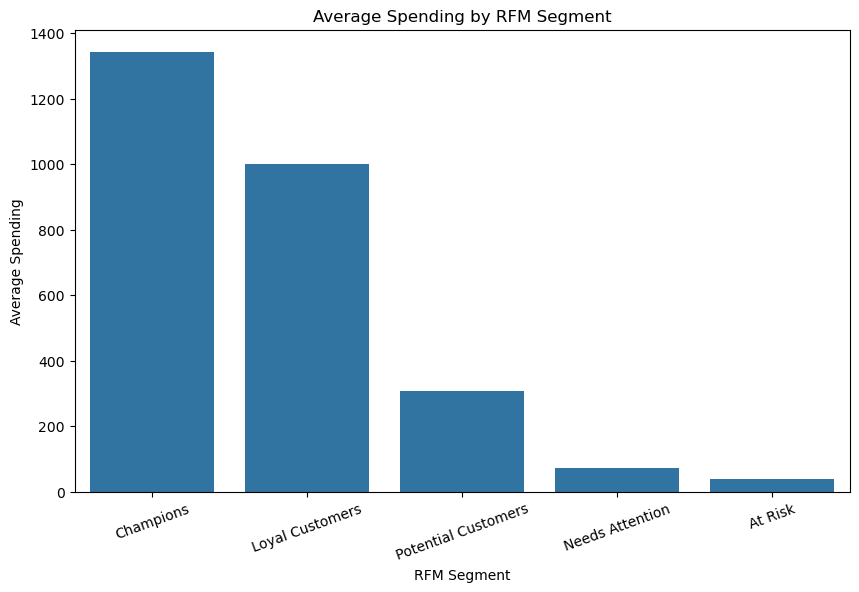

In [44]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=rfm_summary.index,
    y=rfm_summary["Avg_Spending"]
)

plt.title("Average Spending by RFM Segment")
plt.xlabel("RFM Segment")
plt.ylabel("Average Spending")
plt.xticks(rotation=20)
plt.show()


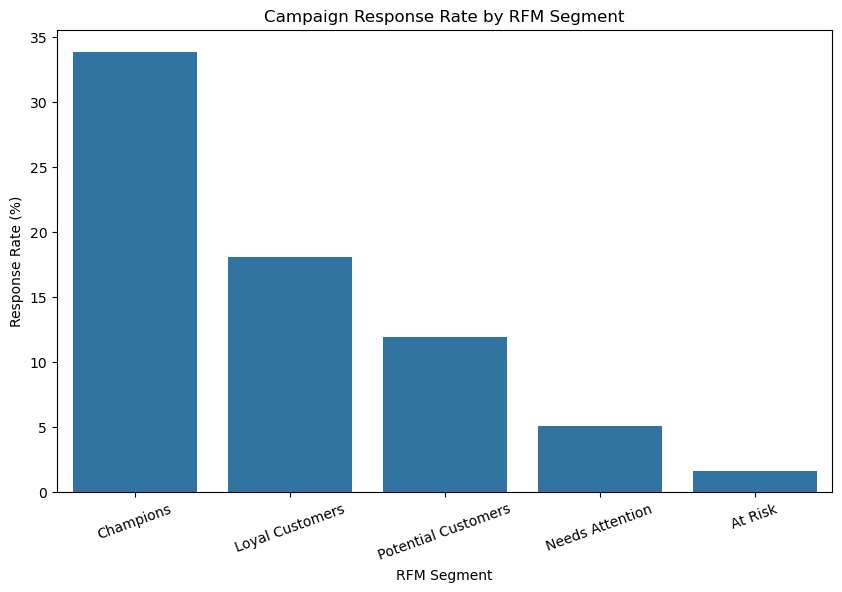

In [45]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=rfm_summary.index,
    y=rfm_summary["Response_Rate"]
)

plt.title("Campaign Response Rate by RFM Segment")
plt.xlabel("RFM Segment")
plt.ylabel("Response Rate (%)")
plt.xticks(rotation=20)
plt.show()

## Identify Target Audiences

In [48]:
#Find High-Value At-Risk Customers

In [47]:
high_value_at_risk = df[
    (df["Customer_Segment"] == "High Value") &
    (df["Recency"] > 90)
].copy()

print("High-Value Customers with Recency > 90:",
      len(high_value_at_risk))

print(
    "Non-Responders:",
    (high_value_at_risk["Response_Status"] == "Non-Responder").sum()
)

print(
    "Historical Spending from Non-Responders:",
    high_value_at_risk.loc[
        high_value_at_risk["Response_Status"] == "Non-Responder",
        "Total_Spending"
    ].sum()
)

High-Value Customers with Recency > 90: 67
Non-Responders: 59
Historical Spending from Non-Responders: 78109


In [49]:
#Create the campaign target label

In [50]:
df["Campaign_Priority"] = "Standard"

In [51]:
df.loc[
    (df["RFM_Segment"] == "Champions"),
    "Campaign_Priority"
] = "Retention"

In [52]:
df.loc[
    (df["Customer_Segment"] == "High Value") &
    (df["Recency"] > 90) &
    (df["Response_Status"] == "Non-Responder"),
    "Campaign_Priority"
] = "Win-Back"

In [53]:
df.loc[
    (df["RFM_Segment"] == "Potential Customers"),
    "Campaign_Priority"
] = "Nurture"

In [54]:
df["Campaign_Priority"].value_counts()

Campaign_Priority
Standard     1203
Nurture       672
Retention     319
Win-Back       46
Name: count, dtype: int64

In [55]:
#final dataset for powerbi dashboard building

In [56]:
df.to_csv(
    "marketing_final_analysis.csv",
    index=False
)

In [57]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("File exported successfully.")

Rows: 2240
Columns: 50
File exported successfully.
